In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

seed = 42
np.random.seed(seed)

# 1 DIMENSION

In [2]:
def update(xk, mu, sigma, delta):
    """
        delta is kind of learning rate
    """
    logex = delta * (mu - 0.5 * sigma * sigma) + sigma * np.sqrt(delta) * np.random.normal(0, 1)
    ex = np.exp(logex)
    return xk * ex

## CONSTANT STEP SIZE

In [3]:
def perform(x0, iters, mu, sigma, delta):
    traj = [x0]
    for _ in range(iters):
        x0 = update(x0, mu, sigma, delta)
        traj.append(x0)

    return traj

In [4]:
# target distribution details
t1 = time.time()

mu = 0
sigma = 1
delta = 1e-2


# initial value
x0 = 0.1
# number of sample paths
num_paths = 10000
paths = []

for index in range(num_paths):
    paths.append(perform(x0, 10000, mu, sigma, delta))
    if (index+1) % 1000 == 0:
        print(f"{index + 1} done")
    
paths = np.array(paths)
print(paths.shape)
t2 = time.time()
print(t2 - t1)

1000 done
2000 done
3000 done
4000 done
5000 done
6000 done
7000 done
8000 done
9000 done
10000 done
(10000, 10001)
330.2306456565857


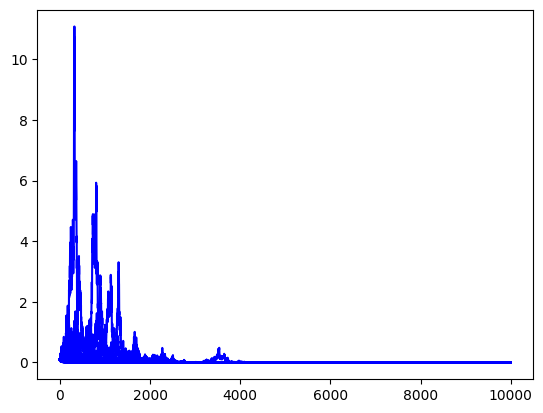

In [5]:
for row in paths[:100]:
    plt.plot(row, 'b')

plt.show()

In [6]:
paths[:,-1]

array([2.27840075e-24, 1.45559471e-17, 7.46043487e-29, ...,
       9.27107889e-17, 8.46128829e-28, 2.65488863e-27])

## VARIABLE STEP SIZE

In [7]:
def performv2(x0, iters, mu, sigma):
    traj = [x0]
    for idx in range(iters):
        delta = (6 / np.pi ** 2) * (1 / ((1 + idx)**2))
        x0 = update(x0, mu, sigma, delta)
        traj.append(x0)

    return traj

In [8]:
t1 = time.time()

mu = 0
sigma = 1
# initial point
x0 = np.exp(sigma**2 / 2)

# number of sample pathsv2
num_paths = 10000
pathsv2 = []

for index in range(num_paths):
    pathsv2.append(performv2(x0, 10000, mu, sigma))
    if (index+1) % 1000 == 0:
        print(f"{index + 1} done")

pathsv2 = np.array(pathsv2)
print(pathsv2.shape)
t2 = time.time()
print(t2 - t1)

1000 done
2000 done
3000 done
4000 done
5000 done
6000 done
7000 done
8000 done
9000 done
10000 done
(10000, 10001)
379.9067425727844


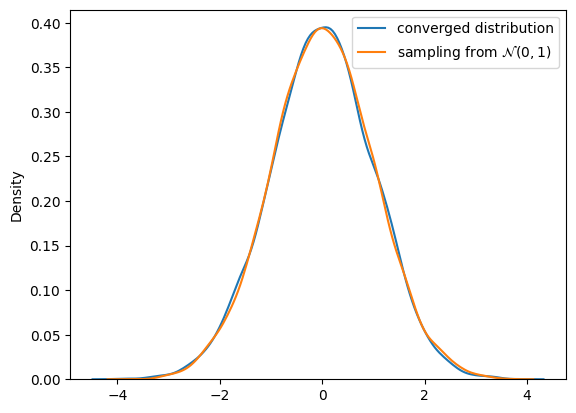

In [9]:
sns.kdeplot(np.log(pathsv2[:, -1]), label="converged distribution")
sns.kdeplot(np.random.normal(0, 1, 10000), label="sampling from $\mathcal{N}(0, 1)$")
plt.legend()
plt.show()

### INITIAL POINT ANALYSIS

In [10]:
def performv3(x0, iters, mu, sigma):
    for idx in range(iters):
        delta = (6 / np.pi ** 2) * (1 / ((1 + idx)**2))
        x0 = update(x0, mu, sigma, delta)

    return x0

In [11]:
t1 = time.time()

mu = 1
sigma = 1

logx0s = [0, 0.25, 0.5 * sigma**2, 1]
x0s = np.exp(logx0s)
allsamples = []

num_paths = 10000

for x0 in x0s:
    print(f"Running for x0 = {x0}")
    finalsamples = []
    for index in range(num_paths):
        finalsamples.append(performv3(x0, 10000, mu, sigma))
        if (index+1) % 1000 == 0:
            print(f"{index + 1} done")
        
    allsamples.append(finalsamples)

allsamples = np.array(allsamples)
print(allsamples.shape)

t2 = time.time()
print(t2 - t1)

Running for x0 = 1.0
1000 done
2000 done
3000 done
4000 done
5000 done
6000 done
7000 done
8000 done
9000 done
10000 done
Running for x0 = 1.2840254166877414
1000 done
2000 done
3000 done
4000 done
5000 done
6000 done
7000 done
8000 done
9000 done
10000 done
Running for x0 = 1.6487212707001282
1000 done
2000 done
3000 done
4000 done
5000 done
6000 done
7000 done
8000 done
9000 done
10000 done
Running for x0 = 2.718281828459045
1000 done
2000 done
3000 done
4000 done
5000 done
6000 done
7000 done
8000 done
9000 done
10000 done
(4, 10000)
1509.3059556484222


In [12]:
print("mu, sigma, log x0, true mean")
for initialpoint, rowsamples in zip(logx0s, allsamples):
    print(np.mean(np.log(rowsamples)), np.var(np.log(rowsamples)), initialpoint, initialpoint + mu - 0.5 * sigma ** 2)

mu, sigma, log x0, true mean
0.5059687750509331 0.991809544073219 0 0.5
0.7595268211234675 1.0105990688678237 0.25 0.75
0.995212467659052 1.0074069181129197 0.5 1.0
1.4909521897637168 1.0171500757145222 1 1.5


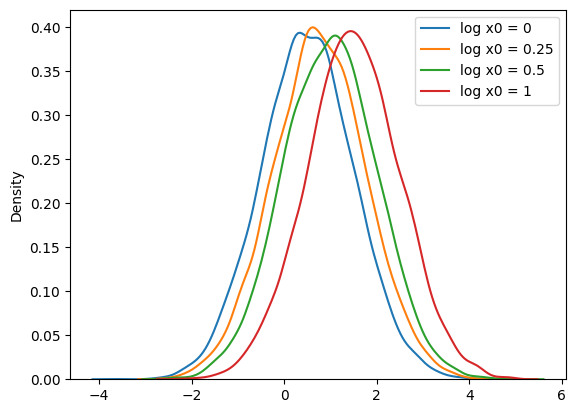

In [13]:
for initialpoint, rowsamples in zip(logx0s, allsamples):
    sns.kdeplot(np.log(rowsamples), label=f"log x0 = {initialpoint}")

plt.legend()
plt.show()

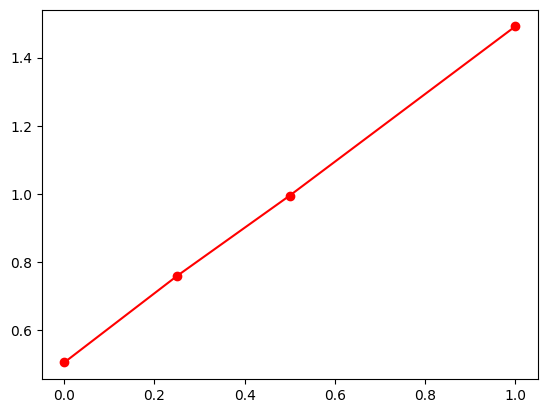

In [14]:
plt.plot(logx0s, np.mean(np.log(allsamples), axis=1), "r", marker="o")
plt.show()